In [1]:
!pip install -q kaggle

In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "PUT_your_api_key"

In [3]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:23<00:00, 126MB/s]



In [4]:
!unzip -q new-plant-diseases-dataset.zip

In [5]:
!ls

'new plant diseases dataset(augmented)'   new-plant-diseases-dataset.zip   test
'New Plant Diseases Dataset(Augmented)'   sample_data


# 🌿 Plant Disease Classification with a CNN

**Goal:** look at a photo of a plant leaf and say which disease it has (or if it is healthy).

**Problem type:** multi-class image classification.

**Tools:** Python 3.11 · TensorFlow / Keras · OpenCV · NumPy · Matplotlib · Seaborn · scikit-learn · pandas

> **About this version:** every code cell from the original notebook is unchanged.
> Only markdown explanations and an **Evaluation** section (at the end) were added.

---

## Dataset

- **Name:** *New Plant Diseases Dataset (Augmented)* on Kaggle (by vipoooool)
  → https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
- **Full dataset:** about 87K RGB leaf images in **38 classes** (healthy and diseased leaves), split **80 % train / 20 % validation** (`train/` and `valid/`, one folder per class).
- The images were made with *offline augmentation* (flips, rotations, etc. were saved to disk in advance).
- A `test` folder with 33 images is also in the download. It has **no class folders**, so this notebook does not use it for scores.

> **Your local copy is a subset.** The training log saved in this notebook shows **410 steps per epoch** (about 13K images), and the model size (8,484,168 parameters) points to **8 classes**.
> Check it yourself with `len(list(folder.iterdir()))`.
> A subset usually has **no `valid` folder** next to `train`. The Evaluation section handles this (see the notes there).

### Folder layout used here

```
data/archive/
└── New Plant Diseases Dataset(Augmented)/
    └── New Plant Diseases Dataset(Augmented)/
        ├── train/    <- used to TRAIN   (one sub-folder per class)
        └── valid/    <- used to EVALUATE (same class folders; comes with the Kaggle download)
```

## How the whole pipeline works

```
image files  →  read (OpenCV)  →  resize 128×128  →  divide by 255  →  batches of 32
      →  tf.data.Dataset  →  CNN (3 Conv blocks + Dense)  →  one probability per class  →  biggest = predicted disease
```

## Notebook map

| Part | What happens |
|---|---|
| Steps 1–3 | Imports, settings, dataset path |
| Steps 4–7 | Helper functions: find files, make labels, load images in batches |
| Step 8 | Wrap the loader in a `tf.data.Dataset` |
| Step 9 | Build and compile the CNN |
| Step 10 | Train and save the model |
| Evaluation | Find evaluation images, loss/accuracy curves, accuracy, precision, recall, F1, confusion matrix |

## Install

```
pip install tensorflow opencv-python numpy matplotlib seaborn scikit-learn pandas
```

## How to run

Run the cells **from top to bottom**. Training reads every training image from disk in every epoch.
In the saved run one epoch took about 1.5 to 3 minutes on CPU (TensorFlow on native Windows does not use the GPU).
If you already trained and saved `model.keras`, you can skip the training cell and go straight to the Evaluation section.

## Step 1 · Imports

| Library | Why it is used |
|---|---|
| `pathlib.Path` | Work with folder and file paths in a clean way |
| `matplotlib.pyplot` | Draw plots (used in the Evaluation section) |
| `cv2` (OpenCV) | Read images from disk and resize them |
| `numpy` | Store images and labels as arrays |
| `tensorflow` / `keras` | Build, train and save the CNN |
| `random` | Shuffle the image list so batches are mixed |

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import random

## Step 2 · Settings

| Name | Value | Meaning |
|---|---|---|
| `IMG_SIZE` | `(128, 128)` | Every image is resized to 128 × 128 pixels. Smaller images = faster training and less memory. |
| `BATCH_SIZE` | `32` | The model sees 32 images at a time, then updates its weights. |
| `EPOCHS` | `15` | One epoch = one full pass over all training images. The model does 15 passes. |
| `SEED` | `42` | Meant for repeatable results. The **training code does not use it**, so shuffling is different on every run. The Evaluation section uses it only to pick the same sample of images every time. |

These values are used by later cells, so change them here only.

In [7]:
IMG_SIZE = (128, 128)  # resize every image to this shape
BATCH_SIZE = 32
EPOCHS = 10
SEED = 42

## Step 3 · Path to the training images

`folder` points to the `train` directory. It has **one sub-folder per class**, and each sub-folder holds the images of that class.

- The `r"..."` (raw string) keeps the backslashes `\` from being treated as special characters.
- The path is **relative**: it starts from the folder where the notebook is running.
- It is written in **Windows style**. Some helper functions below also split text on `"\\"`, so they work on Windows only as written.

`folder` is used by almost every cell after this one.

In [8]:
folder = Path(
    r"/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
)

## Step 4 · `get_all_path(folder)`

**What it does:** returns a list of the path of **every image file** inside all class folders.

**How it works:**
1. Loop over each class folder inside `folder`.
2. Loop over each file inside that class folder.
3. Add the file path to `list_path`.

**Result:** a list of `Path` objects like `.../train/Apple___Apple_scab/xxx.JPG`.

It only stores **paths**, not images, so it is fast and uses almost no memory.

In [9]:
def get_all_path(folder):
    list_path = []
    for i in folder.iterdir():
        temp = Path(i)
        for j in temp.iterdir():
            list_path.append(j)
    return list_path


## Step 5 · `embadding(folder)` (not used in training)

**What it does:** reads **all** images into one big NumPy array and collects a label (the class-folder name) for each one.

**Why it is not part of the pipeline:**
- It does **not resize** images, and it loads everything into RAM at once. One 256 × 256 color image needs about 190 KB, so 10,000 images need about 2 GB (the full 70K-image training set would need about 14 GB).
- The label is taken with `split("\\")[5]`, which only works for this exact Windows path depth.

It stays in the notebook as an early experiment. The real loader is `making_x_and_y` (Step 7).

In [10]:
def embadding(folder):
    images = []
    label = []
    for i in get_all_path(folder):
        img = cv2.imread(str(i))
        if img is None:
            print(f"Warning: could not read {i}")
            continue
        images.append(img)
        label.append(str(i).split("\\")[5])
    # print(label)
    return np.array(images), label

## Step 6 · `making_y(folder)`

**What it does:** builds a dictionary that turns a **class name** into a **class number**.

Example:

```python
{"Apple___Apple_scab": 0, "Apple___Black_rot": 1, "Apple___Cedar_apple_rust": 2, ...}
```

**How it works:**
1. Read the class-folder names from `folder.iterdir()`.
2. Give each name a number with `enumerate` (0, 1, 2, ...).

**Important:** output neuron *i* of the model means class *i*. So this **order must stay the same** in training and in evaluation.
The order comes from `iterdir()` (alphabetical on Windows).

In [11]:
def making_y(folder):
    list_y = []
    for i in folder.iterdir():
        list_y.append(i.name)
    dict = {}
    for i, j in enumerate(list_y):
        dict[j] = i
    return dict

## Step 7 · `making_x_and_y(folder)` (the data loader)

A **generator**: it produces one batch at a time instead of loading all images into memory.

**Steps inside:**
1. `y_dict` = class name → number (from Step 6).
2. `all_paths` = every image path (from Step 4), then **shuffled** so batches are mixed.
3. The inner function `batch(paths)` takes 32 paths and, for each one:
   - reads the image with `cv2.imread` (OpenCV returns colors as **BGR**),
   - skips it and prints a warning if it cannot be read,
   - resizes it to `IMG_SIZE`,
   - gets the label from the **parent folder name**.
4. It divides pixels by **255** so values are between 0 and 1.
5. `yield x, y` sends out one batch, then the loop moves on.

**Shapes:** `x` = `(32, 128, 128, 3)`, `y` = `(32,)`. The last batch can be smaller.

The generator is run again at the start of every epoch, so the images are **re-shuffled every epoch**.

In [12]:
def making_x_and_y(folder):
    y_dict = making_y(folder)
    all_paths = get_all_path(folder)  # list of file paths, built once
    random.shuffle(all_paths)

    def batch(paths):
        images = []
        labels = []
        for p in paths:
            img = cv2.imread(str(p))
            if img is None:
                print(f"Warning: could not read {p}")
                continue
            img = cv2.resize(img, IMG_SIZE)
            images.append(img)
            labels.append(y_dict[p.parent.name])  # class = parent folder name
        return np.array(images) / 255, np.array(labels)

    for i in range(0, len(all_paths), BATCH_SIZE):
        x, y = batch(all_paths[i : i + BATCH_SIZE])
        yield x, y

## Step 8 · `train_ds` (`tf.data.Dataset`)

A plain generator can only be used once. Wrapping it in `tf.data.Dataset.from_generator` lets Keras **restart it every epoch**.

- `lambda: making_x_and_y(folder)` creates a **fresh generator** each time it is called.
- `output_signature` tells TensorFlow what a batch looks like:
  - images: `(None, 128, 128, 3)`, `float32`
  - labels: `(None,)`, `int32`
- `None` means the batch size can change (the last batch is smaller).

Nothing is loaded yet. Images are read **while training runs**.

In [13]:
# wrap in tf.data.Dataset so it can restart each epoch (plain generators can't)
train_ds = tf.data.Dataset.from_generator(
    lambda: making_x_and_y(folder),
    output_signature=(
        tf.TensorSpec(shape=(None, IMG_SIZE[0], IMG_SIZE[1], 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.int32),
    ),
)

## Step 9 · `model()` (build and compile the CNN)

`num_classes` is the number of folders inside `folder` (8 in the saved run, 38 for the full dataset).

**Layers**

| # | Layer | Output shape | What it does |
|---|---|---|---|
| 1 | `Input` | 128 × 128 × 3 | Accepts a color image |
| 2 | `Conv2D(32, 3×3, relu)` | 128 × 128 × 32 | Finds simple patterns (edges, colors) |
| 3 | `MaxPooling2D(2×2)` | 64 × 64 × 32 | Halves the size, keeps the strongest signals |
| 4 | `Conv2D(64, 3×3, relu)` | 64 × 64 × 64 | Finds bigger patterns (spots, texture) |
| 5 | `MaxPooling2D(2×2)` | 32 × 32 × 64 | Halves the size again |
| 6 | `Conv2D(128, 3×3, relu)` | 32 × 32 × 128 | Finds complex shapes |
| 7 | `MaxPooling2D(2×2)` | 16 × 16 × 128 | Halves the size again |
| 8 | `Flatten` | 32,768 | Turns the feature maps into one long vector |
| 9 | `Dense(256, relu)` | 256 | Combines the features |
| 10 | `Dropout(0.5)` | 256 | Randomly switches off half of the neurons in training to reduce overfitting |
| 11 | `Dense(num_classes, softmax)` | `num_classes` | One probability per class (all add up to 1) |

`padding="same"` keeps the image size after each convolution.
Total: about **8.5 million** parameters (8,484,168 in the saved run). Almost all of them (about 8.39 M) are in the first `Dense` layer.

**Compile**
- `optimizer="adam"`: adjusts the weights automatically.
- `loss="sparse_categorical_crossentropy"`: used because labels are **whole numbers** (0, 1, 2, ...), not one-hot vectors.
- `metrics=["accuracy"]`: reports the share of correct predictions.

**Callbacks** (created and returned together with the model)

| Callback | Idea |
|---|---|
| `EarlyStopping` | Stop when `val_loss` stops improving and restore the best weights |
| `ModelCheckpoint` | Save the best model to `best_plant_disease_model.keras` |
| `ReduceLROnPlateau` | Halve the learning rate when `val_loss` stalls |

> ⚠️ In Step 10 these callbacks are **not passed to `fit()`**, and there is **no validation data**, so they do nothing in this version.
> They watch `val_loss` / `val_accuracy`, which only exist when `validation_data` is given.

In [14]:
def model():
    num_classes = len(list(folder.iterdir()))

    cnn = models.Sequential(
        [
            layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
            layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D(2, 2),
            layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D(2, 2),
            layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D(2, 2),
            layers.Flatten(),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.5),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )

    cnn.compile(
        optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
    )

    cnn.summary()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        ),
        tf.keras.callbacks.ModelCheckpoint(
            "best_plant_disease_model.keras",
            monitor="val_accuracy",
            save_best_only=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
        ),
    ]

    return cnn, callbacks

## Step 10 · Train and save

- `model()` returns the compiled network `cnn` and the `callbacks` list.
- `cnn.fit(train_ds, epochs=EPOCHS)` trains for 15 epochs. In each epoch the model sees every training image once (saved run: 410 steps of 32 images).
- The result is stored in `history`. In this version it only has `loss` and `accuracy` (training data), no `val_*` keys.
- The trained model is saved twice:
  - `model.keras` → the current Keras format (use this one),
  - `model.h5` → the older HDF5 format. Keras prints a "legacy format" warning for it, which is harmless.

In the saved run, training accuracy went from about 0.67 in epoch 1 to about 0.99 in epoch 15.

In [15]:
cnn, callbacks = model()

history = cnn.fit(
    train_ds,
    epochs=EPOCHS,
)
cnn.save("model.keras")
cnn.save("model.h5")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,491,878 (32.39 MB)

 Trainable params: 8,491,878 (32.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 94s 39ms/step - accuracy: 0.5719 - loss: 1.4544
Epoch 2/10


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 84s 38ms/step - accuracy: 0.7988 - loss: 0.6373
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 77s 35ms/step - accuracy: 0.8569 - loss: 0.4444
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 80s 36ms/step - accuracy: 0.8896 - loss: 0.3368
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 81s 37ms/step - accuracy: 0.9124 - loss: 0.2708
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 77s 35ms/step - accuracy: 0.9260 - loss: 0.2278
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 77s 35ms/step - accuracy: 0.9367 - loss: 0.1949
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 76s 34ms/step - accuracy: 0.9433 - loss: 0.1764
Epoch 9/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 78s 35ms/step - accuracy: 0.9498 - loss: 0.1552
Epoch 10/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 76s 34ms/step - accuracy: 0.9539 - loss: 0.1397


## What to know about this version

These points are only **explained** here. The code was not changed.

| Point | What it means |
|---|---|
| Callbacks are not used | `fit()` gets no `callbacks=` and no `validation_data=`. Early stopping, best-model saving and learning-rate reduction do not run. |
| No validation while training | You cannot see overfitting during training. The Evaluation section checks the model afterwards on validation images. |
| Keras warnings in the log | `shuffle=True ... will be ignored` and `Your input ran out of data` are printed because `train_ds` comes from a generator of unknown length. The loader already shuffles by itself, and the saved run still finished all 15 epochs with 410 steps each. |
| `SEED` is not used | Training results change from run to run. |
| Windows-only paths | `split("\\")` in `making_y` and `embadding` breaks on macOS/Linux. |
| `embadding()` is unused | Kept as an experiment only. |
| No `.prefetch()` | Images are read from disk while the model waits, so training is slower than it could be. |
| BGR color order | OpenCV loads BGR. This is fine as long as **training and evaluation use the same order**. The evaluation code does. |

# 📊 Evaluation

Now we check how good the trained model is on images it did **not train on**.

## Words used in this section

| Term | Simple meaning |
|---|---|
| **Accuracy** | Correct predictions ÷ all predictions |
| **Precision** | Of the images the model called class X, how many really were X? *(few false alarms)* |
| **Recall** | Of the images that really are class X, how many did the model find? *(few misses)* |
| **F1-score** | One number that balances precision and recall |
| **Macro average** | Simple average over the classes (every class counts the same) |
| **Weighted average** | Average over the classes, weighted by how many images each class has |
| **Top-3 accuracy** | The real class is among the 3 highest probabilities |
| **Confusion matrix** | Table: rows = true class, columns = predicted class. The **diagonal** is correct, everything else is a mistake. |

## Where do the evaluation images come from?

The notebook tries these in order:

1. **`VALID_FOLDER`**: a path you set by hand (Eval 4).
2. **Automatic search**: it looks next to `train` and a few folders above for a folder that has your class folders (best case: the `valid` folder of the Kaggle download).
3. **Fallback**: if nothing is found, it uses a **sample of train images** so the notebook still runs. Every result is then labeled **"TRAIN images (NOT a fair test)"**, because the model has already seen these images.

Only the classes that exist in **your `train` folder** are evaluated, even if `valid` has more (the full dataset has 38).

**To get a real test:** download the Kaggle dataset and copy its `valid` folder next to your `train` folder (or set `VALID_FOLDER`).

## What the next cells do

| Cell | Job |
|---|---|
| Eval 1 | Imports |
| Eval 2 | Load the model and the class names |
| Eval 3 | Helper functions to find and list evaluation images |
| Eval 4 | Choose the evaluation images |
| Eval 5 | Plot loss and accuracy per epoch |
| Eval 6 | `evaluate_model`: predict every image |
| Eval 7 | Accuracy, precision, recall, F1, class report |
| Eval 8 | Confusion matrix |
| Eval 9 | Weakest classes and most common mistakes |

> The evaluation uses the **same preprocessing as training**: OpenCV read (BGR) → resize to `IMG_SIZE` → divide by 255.

### Eval 1 · Imports

Extra libraries for evaluation. If one is missing: `pip install seaborn scikit-learn pandas`.

In [16]:
import os
import seaborn as sns
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

sns.set_theme(style="whitegrid")

### Eval 2 · Model and class names

- **Step A:** uses `cnn` from memory. If the notebook was restarted, it loads `model.keras` from disk (and tells you if that file does not exist).
- **Step B:** rebuilds the class numbers in **the same order as `making_y(folder)`**, so predictions map to the right class names.
- It prints every class with its number, so you can check the list.

In [ ]:
if "cnn" not in globals():
    if not Path("model.keras").exists():
        raise FileNotFoundError(
            "No trained model found. Run the training cell first (it saves model.keras)."
        )
    cnn = tf.keras.models.load_model("model.keras")
    print("Loaded model.keras from disk")
else:
    print("Using the model that is already in memory")

class_to_idx = {}
for number, class_dir in enumerate(folder.iterdir()):
    class_to_idx[class_dir.name] = number

class_names = list(class_to_idx.keys())
print("Number of classes:", len(class_names))
for number, name in enumerate(class_names):
    print(f"  {number}: {name}")

Using the model that is already in memory
Number of classes: 38
  0: Cherry_(including_sour)___healthy
  1: Peach___Bacterial_spot
  2: Tomato___Bacterial_spot
  3: Potato___healthy
  4: Apple___healthy
  5: Soybean___healthy
  6: Strawberry___healthy
  7: Grape___Black_rot
  8: Cherry_(including_sour)___Powdery_mildew
  9: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  10: Tomato___Leaf_Mold
  11: Potato___Late_blight
  12: Pepper,_bell___Bacterial_spot
  13: Apple___Cedar_apple_rust
  14: Tomato___Tomato_Yellow_Leaf_Curl_Virus
  15: Tomato___Target_Spot
  16: Apple___Apple_scab
  17: Corn_(maize)___Northern_Leaf_Blight
  18: Tomato___Late_blight
  19: Tomato___Spider_mites Two-spotted_spider_mite
  20: Corn_(maize)___healthy
  21: Pepper,_bell___healthy
  22: Squash___Powdery_mildew
  23: Grape___Esca_(Black_Measles)
  24: Tomato___healthy
  25: Apple___Black_rot
  26: Raspberry___healthy
  27: Tomato___Septoria_leaf_spot
  28: Tomato___Early_blight
  29: Peach___healthy
  30: Corn_(ma

### Eval 3 · Helper functions for the evaluation images

This cell only **defines** two functions. Nothing is loaded yet.

- `find_validation_folder(train_folder, class_names)`: walks through the folders near `train` and returns the first folder that contains your class folders. It prefers folders called `valid`, `val` or `validation`, and it never picks a folder called `train`. It returns `None` if nothing is found.
- `collect_images(eval_folder, class_to_idx, per_class)`: returns a list of `(image_path, class_number)`. It skips files that are not images (like `Thumbs.db`), ignores class folders that are not in your `train` folder, and prints a warning if one of your classes is missing.

In [ ]:
IMAGE_TYPES = {".jpg", ".jpeg", ".png", ".bmp"}


def find_validation_folder(train_folder, class_names):
    """Search near the train folder for another folder that has the same class sub-folders.

    Returns the folder, or None if nothing was found.
    """
    train_folder = train_folder.resolve() 
    wanted = set(class_names)
    good_names = ["valid", "val", "validation"]
    never_use = ["train", "training"]
    skip = {".git", ".venv", "venv", "__pycache__", "node_modules", "site-packages"}

    for levels_up in range(1, 5):
        if levels_up > len(train_folder.parents):
            break
        start = train_folder.parents[levels_up - 1]
        matches = []

        for current, sub_dirs, _files in os.walk(start):
            current = Path(current)
            depth = len(current.relative_to(start).parts)

            
            sub_dirs[:] = [
                d for d in sub_dirs if d not in skip and (current / d) != train_folder
            ]

        
            found = wanted & set(sub_dirs)
            enough = len(found) >= max(1, len(wanted) // 2)
            if enough and current.name.lower() not in never_use:
                matches.append(current)
                sub_dirs[:] = []  
            elif depth >= 3:
                sub_dirs[:] = []  

        if matches:
            for match in matches:  
                if match.name.lower() in good_names:
                    return match
            return matches[0]

    return None


def collect_images(eval_folder, class_to_idx, per_class=None):
    picker = random.Random(SEED)  # same pick every run
    items = []
    for class_name, class_number in class_to_idx.items():
        class_dir = eval_folder / class_name
        if not class_dir.is_dir():
            print(f"Warning: class folder not found in {eval_folder.name}: {class_name}")
            continue

        files = sorted(f for f in class_dir.iterdir() if f.suffix.lower() in IMAGE_TYPES)
        if per_class is not None and len(files) > per_class:
            files = picker.sample(files, per_class)

        for f in files:
            items.append((f, class_number))
    return items

### Eval 4 · Choose the evaluation images

Two settings at the top can be changed:

| Setting | Default | Meaning |
|---|---|---|
| `VALID_FOLDER` | `None` | Search automatically. Or give a path, e.g. `Path(r"D:\data\valid")` |
| `IMAGES_PER_CLASS` | `None` | Use all validation images. Set a number (for example `50`) for a fast test run. |

If no validation folder exists, a clear **WARNING** is printed and a sample of train images is used instead (`FALLBACK_IMAGES_PER_CLASS`).

In [ ]:
VALID_FOLDER = None  # None = search automatically. Or set your own, e.g. Path(r"D:\data\valid")
IMAGES_PER_CLASS = None  # None = use every validation image. Use 50 for a quick test run.
FALLBACK_IMAGES_PER_CLASS = 100  # only used when no validation folder exists


if VALID_FOLDER is not None:
    valid_folder = Path(VALID_FOLDER)
    if not valid_folder.is_dir():
        raise FileNotFoundError(f"VALID_FOLDER does not exist: {valid_folder}")
else:
    print("Looking for a validation folder near:", folder.resolve())
    valid_folder = find_validation_folder(folder, class_names)

if valid_folder is not None:
    eval_source = "validation images"
    eval_items = collect_images(valid_folder, class_to_idx, IMAGES_PER_CLASS)
    print("Validation folder found:", valid_folder)
else:
    eval_source = "TRAIN images (NOT a fair test)"
    eval_items = collect_images(folder, class_to_idx, FALLBACK_IMAGES_PER_CLASS)
    print("=" * 72)
    print("WARNING: no validation folder was found.")
    print("The results below use a sample of TRAIN images, which the model already saw.")
    print("They only show that the code works. They are NOT a fair test.")
    print()
    print("To get a real test:")
    print("  1. Download the dataset: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset")
    print("  2. Copy its 'valid' folder next to your 'train' folder")
    print("     (or set VALID_FOLDER above to its path) and run this cell again.")
    print("Only the classes that exist in your train folder are used.")
    print("=" * 72)

print("Images to evaluate:", len(eval_items))
if len(eval_items) == 0:
    raise ValueError(
        "No images were found for evaluation. Check that the class folder names "
        "match the ones in your train folder."
    )

Looking for a validation folder near: /content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Validation folder found: /content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Images to evaluate: 17572


### Eval 5 · Training history

`plot_history(history)` draws two charts, **loss** and **accuracy**, for every epoch.

- A validation line is drawn only if `history` has `val_*` values. In this version training has no validation data, so you will see **the training lines only**.
- The figure is saved as `training_history.png`.
- If the notebook was restarted, `history` no longer exists. Train again to get the curves.

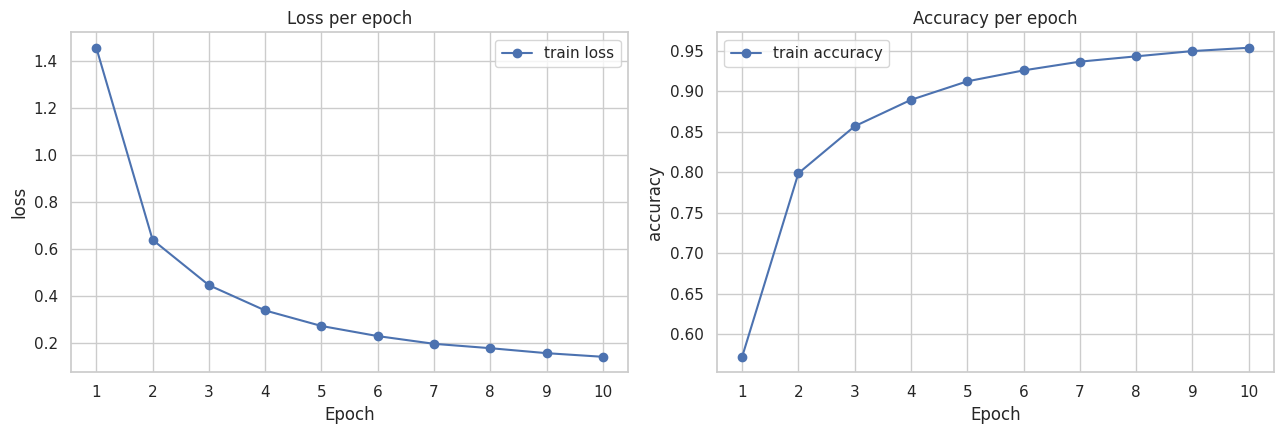

In [20]:
def plot_history(history):
    """Draw loss and accuracy for every epoch (Keras History object or plain dict)."""
    hist = history.history if hasattr(history, "history") else history

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, metric in zip(axes, ["loss", "accuracy"]):
        if metric not in hist:
            ax.set_visible(False)
            continue

        epochs = list(range(1, len(hist[metric]) + 1))
        ax.plot(epochs, hist[metric], marker="o", label=f"train {metric}")
        if f"val_{metric}" in hist:  # only exists when fit() got validation_data
            ax.plot(epochs, hist[f"val_{metric}"], marker="s", label=f"validation {metric}")

        ax.set_title(f"{metric.capitalize()} per epoch")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric)
        if len(epochs) <= 30:
            ax.set_xticks(epochs)
        ax.legend()

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
    plt.show()


if "history" in globals():
    plot_history(history)
else:
    print("`history` not found. Run the training cell first to see the curves.")

### Eval 6 · `evaluate_model`

Predicts every image and returns three things:

| Output | Meaning |
|---|---|
| `y_true` | Real class numbers (from the folder names) |
| `y_pred` | Predicted class numbers (the highest probability) |
| `y_prob` | The probabilities for every class, for each image |

Images are processed in batches of `BATCH_SIZE`, so memory stays low. Unreadable images are skipped with a warning. If the model and the class list do not match, you get a clear error message.

In [21]:
def evaluate_model(cnn, items):
    """Predict every image in `items` (a list of (path, class_number) pairs).

    Returns:
      y_true : the real class numbers
      y_pred : the class numbers the model predicted
      y_prob : the model's probabilities, one row per image, one column per class
    """
    y_true = []
    all_probs = []

    for start in range(0, len(items), BATCH_SIZE):
        images = []
        labels = []
        for path, class_number in items[start : start + BATCH_SIZE]:
            img = cv2.imread(str(path))  # BGR colors, same as training
            if img is None:
                print(f"Warning: could not read {path}")
                continue
            images.append(cv2.resize(img, IMG_SIZE))  # same size as training
            labels.append(class_number)

        if len(images) == 0:
            continue

        batch = np.array(images).astype("float32") / 255  # same /255 scaling as training
        probs = cnn.predict(batch, verbose=0)

        if probs.shape[1] != len(class_names):
            raise ValueError(
                f"The model has {probs.shape[1]} outputs but the train folder has "
                f"{len(class_names)} classes. Train again, or load the matching model."
            )

        all_probs.append(probs)
        y_true.extend(labels)

        if (start // BATCH_SIZE) % 100 == 0:
            print(f"  {start}/{len(items)} images done")

    if len(all_probs) == 0:
        raise ValueError("None of the evaluation images could be read.")

    y_prob = np.vstack(all_probs)
    y_pred = y_prob.argmax(axis=1)  # the biggest probability = predicted class
    return np.array(y_true), y_pred, y_prob

### Eval 7 · Run the evaluation and print the metrics

Prints **accuracy, top-3 accuracy, macro/weighted precision, recall and F1**, and the full per-class report.
The first line says which images were used (`validation images` or `TRAIN images (NOT a fair test)`).
A class with no evaluation image is left out of the averages, and a note tells you which one.

In [ ]:
y_true, y_pred, y_prob = evaluate_model(cnn, eval_items)
all_class_numbers = list(range(len(class_names)))

# Only score classes that really have evaluation images.
# (A class with no images would count as 0 and pull the averages down.)
classes_used = sorted(set(y_true))
names_used = [class_names[i] for i in classes_used]
if len(classes_used) < len(class_names):
    missing = [class_names[i] for i in all_class_numbers if i not in classes_used]
    print("Note: no evaluation images for these classes, so they are left out:", missing)

# ---------- Accuracy ----------
accuracy = accuracy_score(y_true, y_pred)


top3_hits = 0
for real_class, probs in zip(y_true, y_prob):
    best_three = np.argsort(probs)[-3:]
    if real_class in best_three:
        top3_hits += 1
top3_accuracy = top3_hits / len(y_true)

# ---------- Precision, recall, F1 (macro and weighted averages) ----------
rows = []
for average in ["macro", "weighted"]:
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=classes_used, average=average, zero_division=0
    )
    rows.append({"average": average, "precision": precision, "recall": recall, "f1": f1})
summary = pd.DataFrame(rows).set_index("average")

print()
print("Results on:", eval_source)
print(f"Images evaluated : {len(y_true)}")
print(f"Accuracy         : {accuracy:.4f}")
print(f"Top-3 accuracy   : {top3_accuracy:.4f}")
print()
print(summary.round(4).to_string())


print()
print(
    classification_report(
        y_true,
        y_pred,
        labels=classes_used,
        target_names=names_used,
        digits=4,
        zero_division=0,
    )
)

  0/17572 images done
  3200/17572 images done
  6400/17572 images done
  9600/17572 images done
  12800/17572 images done
  16000/17572 images done

Results on: validation images
Images evaluated : 17572
Accuracy         : 0.9515
Top-3 accuracy   : 0.9945

          precision  recall      f1
average                            
macro        0.9524  0.9514  0.9515
weighted     0.9525  0.9515  0.9515

                                                    precision    recall  f1-score   support

                 Cherry_(including_sour)___healthy     0.9760    0.9803    0.9781       456
                            Peach___Bacterial_spot     0.9881    0.9041    0.9443       459
                           Tomato___Bacterial_spot     0.9703    0.9224    0.9457       425
                                  Potato___healthy     0.9454    0.9496    0.9475       456
                                   Apple___healthy     0.9119    0.9482    0.9297       502
                                 Soybean___h

### Eval 8 · Confusion matrix

- **Counts:** how many images went from the true class (row) to the predicted class (column).
- **Normalized:** each row is divided by its total, so the diagonal is the **recall of that class**.

Bright cells **off the diagonal** are mistakes. Both figures are saved as PNG files. With 20 classes or fewer, the numbers are written inside the cells.

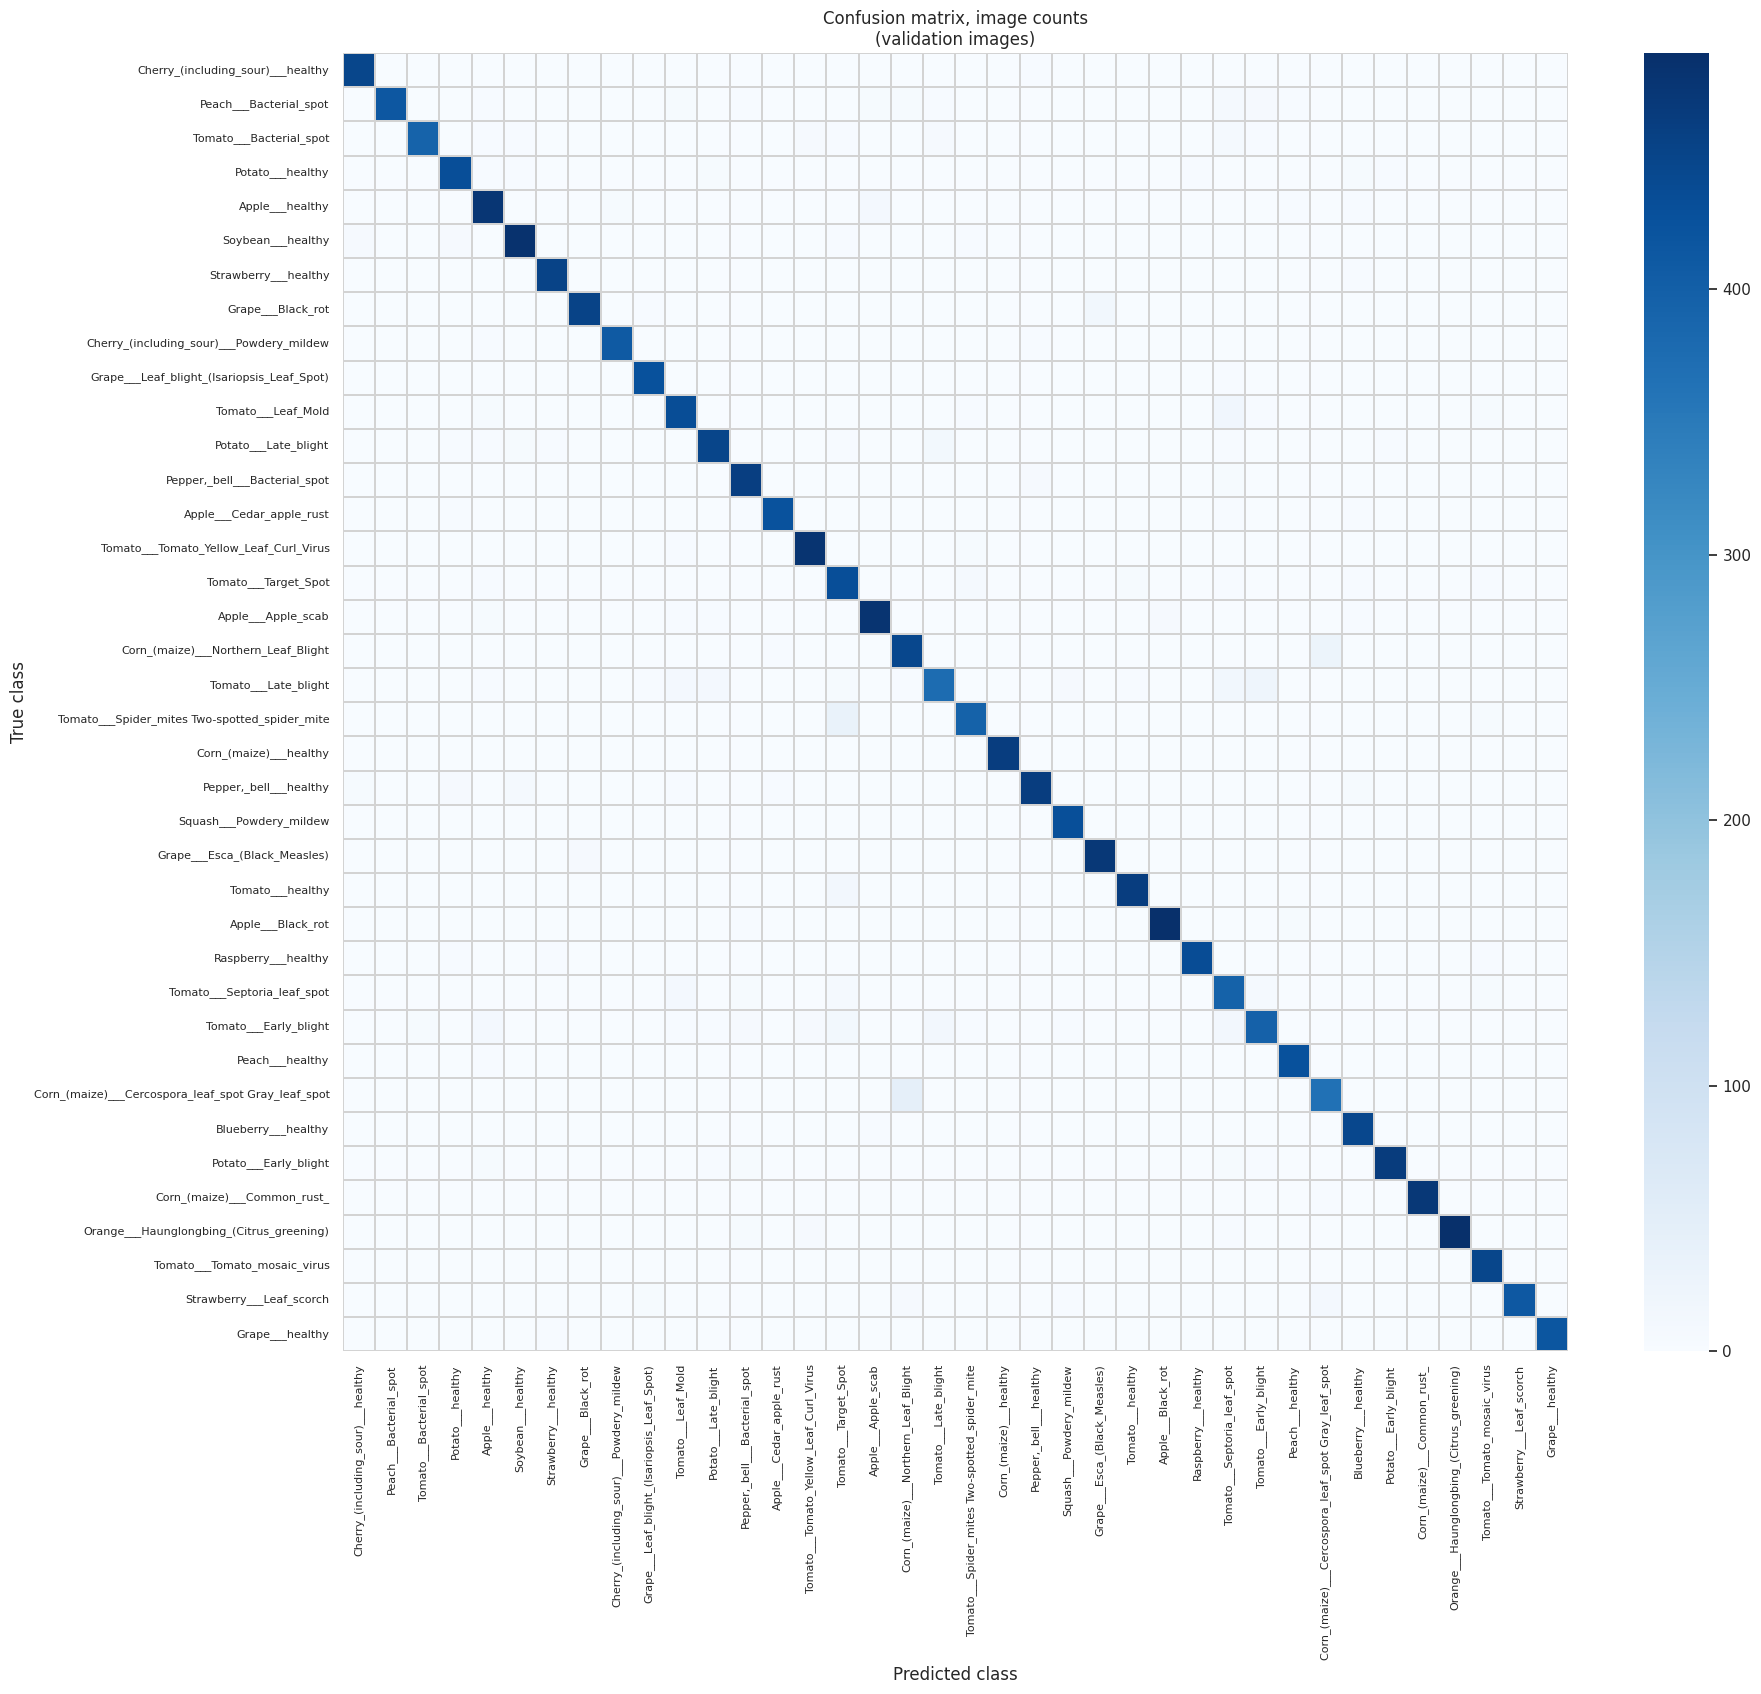

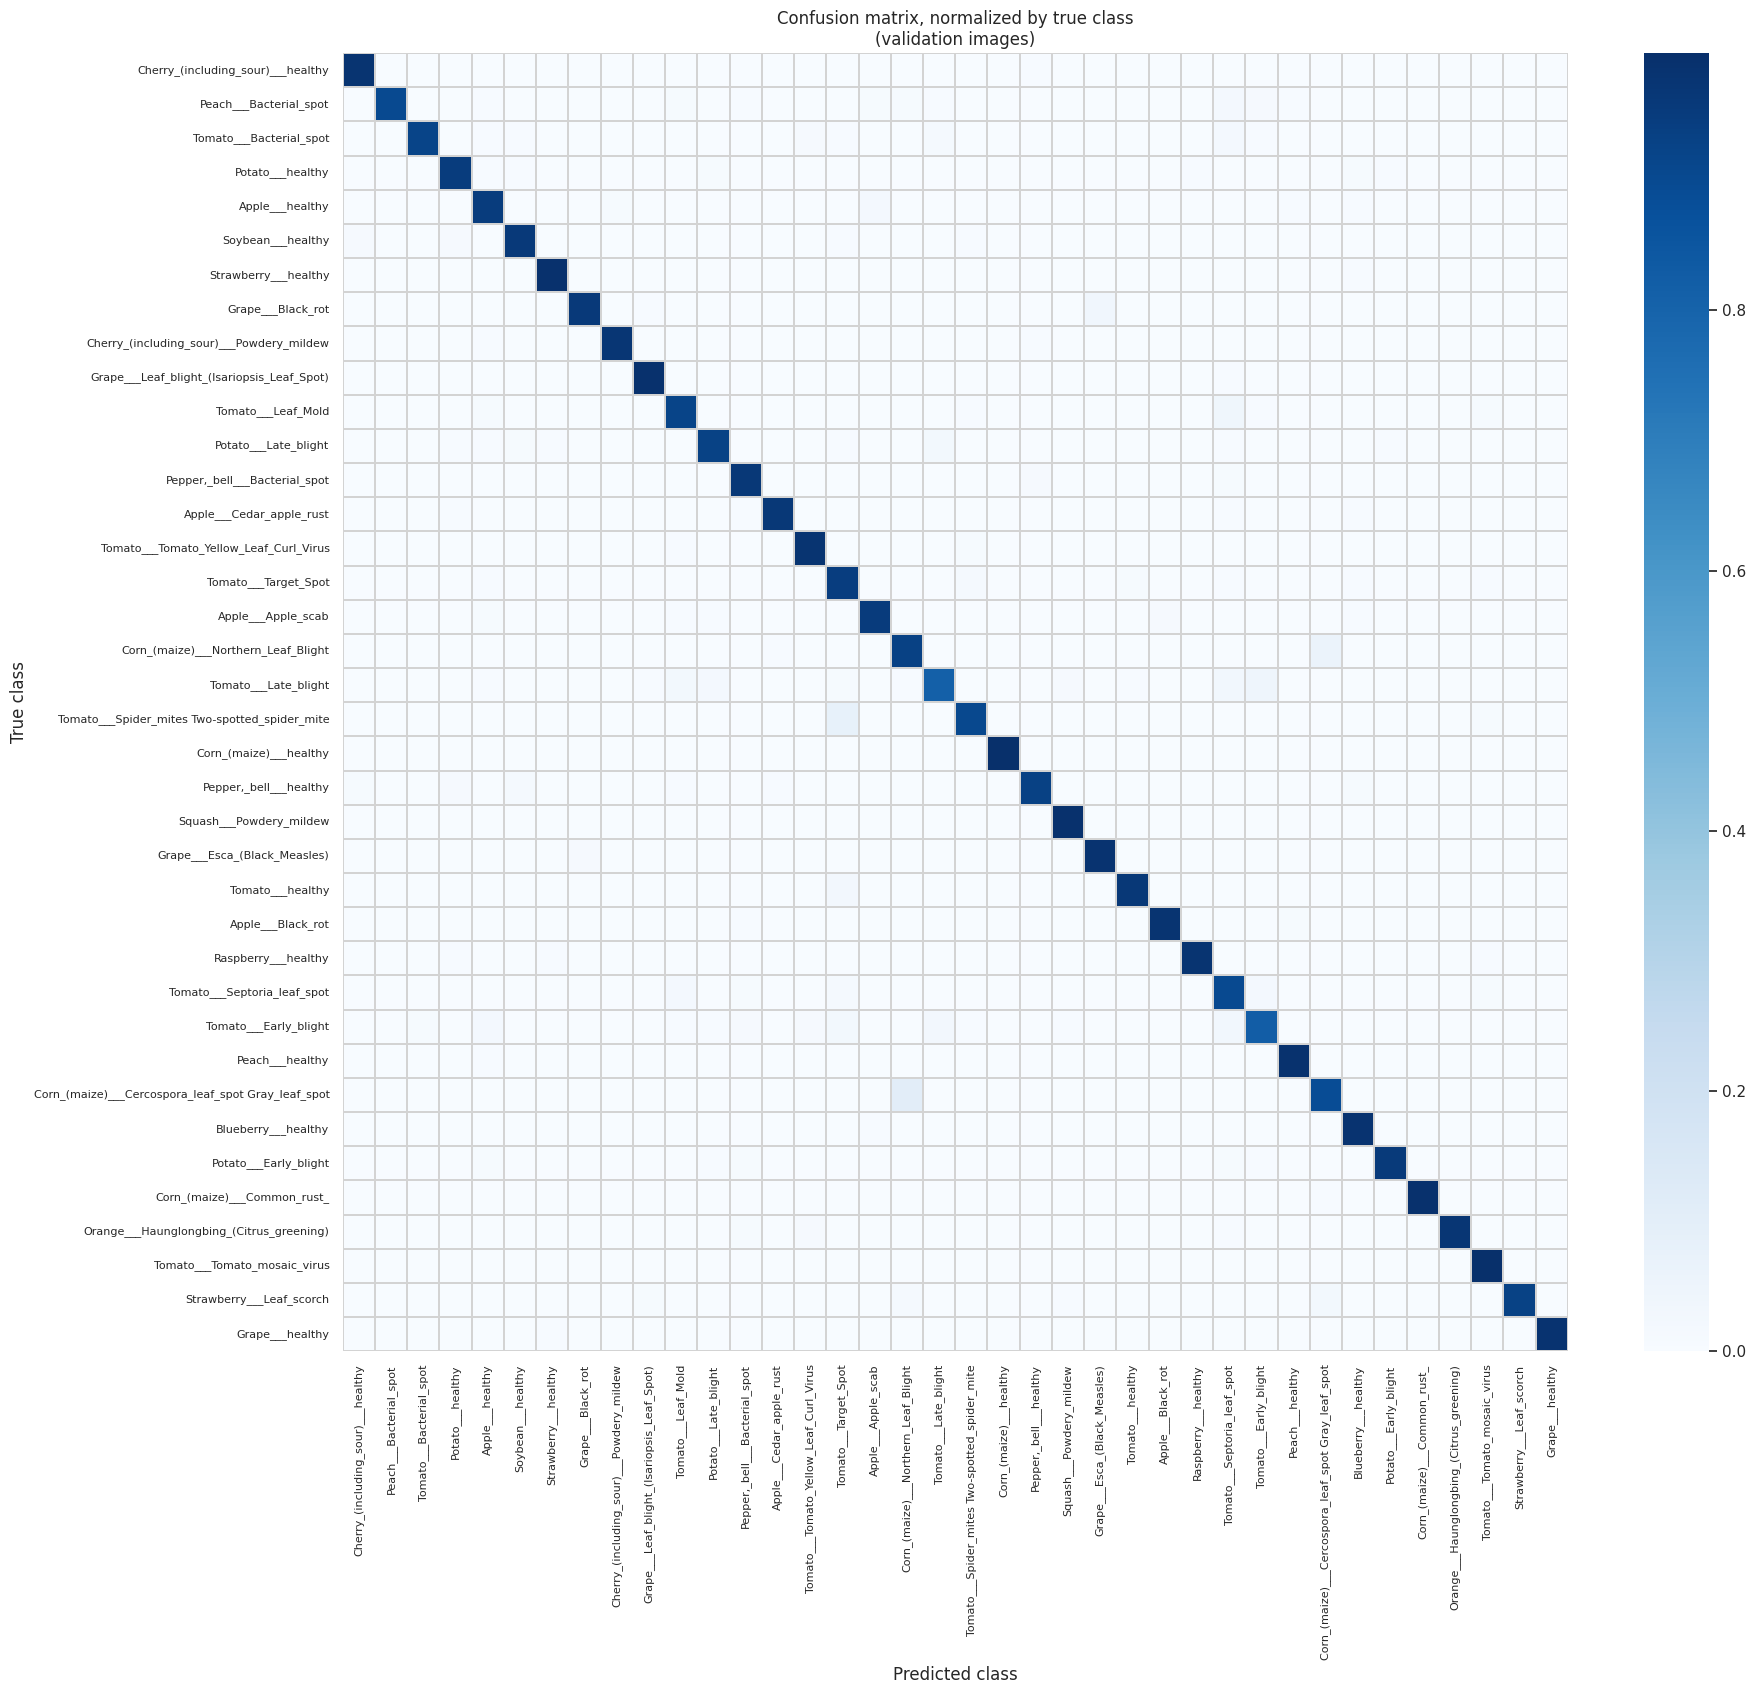

In [23]:
def plot_confusion_matrix(cm, class_names, source, normalize=False, filename=None):
    """Draw a confusion matrix. normalize=True shows row percentages (= recall per class)."""
    if normalize:
        row_totals = cm.sum(axis=1, keepdims=True)
        row_totals[row_totals == 0] = 1  # avoid dividing by zero
        cm = cm / row_totals
        number_format = ".2f"
        title = f"Confusion matrix, normalized by true class\n({source})"
    else:
        number_format = "d"
        title = f"Confusion matrix, image counts\n({source})"

    n = len(class_names)
    fig, ax = plt.subplots(figsize=(max(9, n * 0.5), max(8, n * 0.45)))
    sns.heatmap(
        cm,
        cmap="Blues",
        annot=(n <= 20),  # write the numbers inside the cells only when there are few classes
        fmt=number_format,
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.2,
        linecolor="lightgrey",
        ax=ax,
    )
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


cm = confusion_matrix(y_true, y_pred, labels=all_class_numbers)
plot_confusion_matrix(cm, class_names, eval_source, normalize=False, filename="confusion_matrix.png")
plot_confusion_matrix(cm, class_names, eval_source, normalize=True, filename="confusion_matrix_normalized.png")

### Eval 9 · Weakest classes and most common mistakes

- Bar chart of the F1-score for every class, lowest first.
- Table of the 5 weakest classes.
- The most frequent confusions (true class → predicted class).

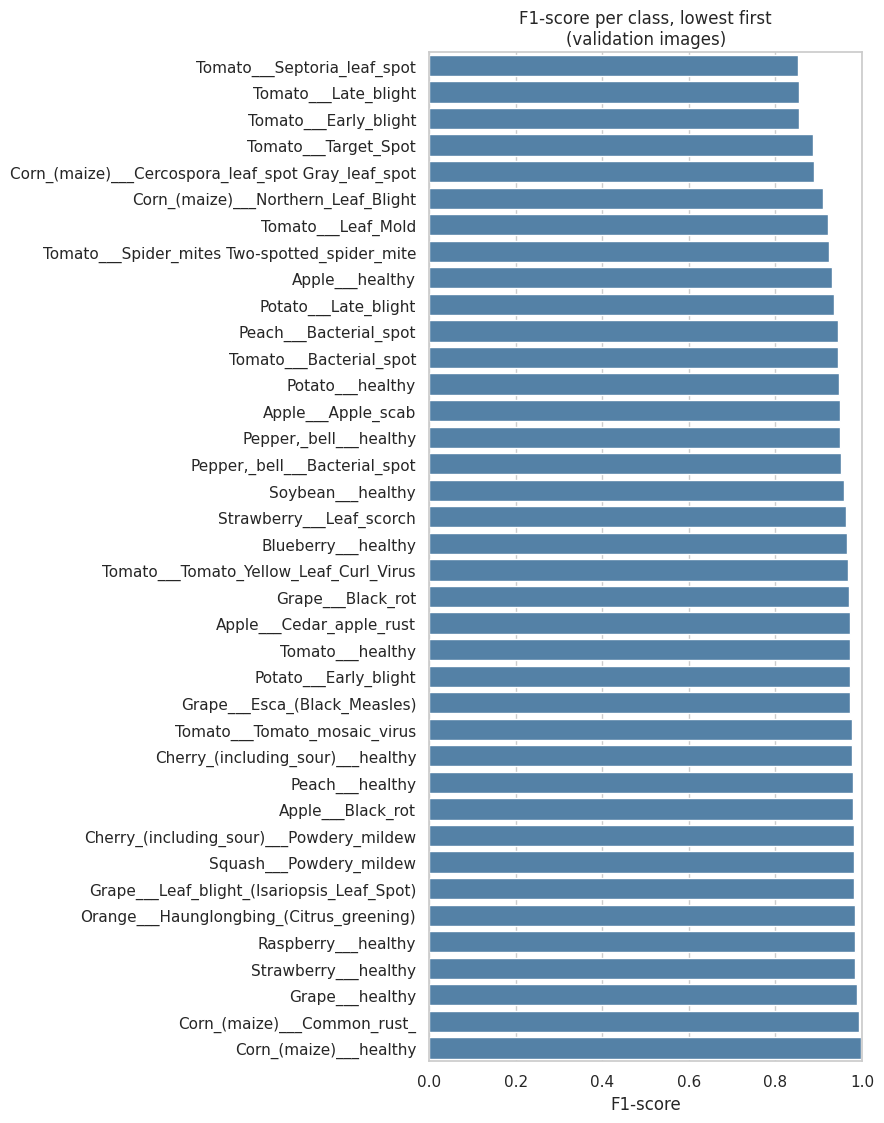

Weakest classes:
                                             class  precision  recall     f1  images
                       Tomato___Septoria_leaf_spot     0.8057  0.9037 0.8519     436
                              Tomato___Late_blight     0.8995  0.8121 0.8536     463
                             Tomato___Early_blight     0.8859  0.8250 0.8544     480
                              Tomato___Target_Spot     0.8356  0.9453 0.8871     457
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8902  0.8902 0.8902     410

Most common mistakes (true class -> predicted class):
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot  ->  Corn_(maize)___Northern_Leaf_Blight : 44 images
  Tomato___Spider_mites Two-spotted_spider_mite  ->  Tomato___Target_Spot : 35 images
  Corn_(maize)___Northern_Leaf_Blight  ->  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 28 images
  Tomato___Late_blight  ->  Tomato___Early_blight : 22 images
  Tomato___Leaf_Mold  ->  Tomato___Septoria_leaf_spot : 19

In [24]:
# ---------- Precision, recall and F1 for each class ----------
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=all_class_numbers, zero_division=0
)
per_class = pd.DataFrame(
    {
        "class": class_names,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "images": support,
    }
).sort_values("f1")  # weakest class first
per_class = per_class[per_class["images"] > 0]  # skip classes that have no evaluation images

fig, ax = plt.subplots(figsize=(9, max(4, len(class_names) * 0.3)))
sns.barplot(data=per_class, x="f1", y="class", orient="h", color="steelblue", ax=ax)
ax.set_xlim(0, 1)
ax.set_xlabel("F1-score")
ax.set_ylabel("")
ax.set_title(f"F1-score per class, lowest first\n({eval_source})")
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()

print("Weakest classes:")
print(per_class.head(5).round(4).to_string(index=False))

# ---------- Most common mistakes ----------
# Every cell of the confusion matrix outside the diagonal is a mistake.
mistakes = []
for true_number in range(len(class_names)):
    for predicted_number in range(len(class_names)):
        count = cm[true_number][predicted_number]
        if true_number != predicted_number and count > 0:
            mistakes.append((count, class_names[true_number], class_names[predicted_number]))
mistakes.sort(reverse=True)  # biggest first

print()
print("Most common mistakes (true class -> predicted class):")
if len(mistakes) == 0:
    print("  No mistakes at all.")
for count, true_name, predicted_name in mistakes[:5]:
    print(f"  {true_name}  ->  {predicted_name} : {count} images")

## ✅ How to read the results

- **Accuracy is high but macro-F1 is lower?** Some classes are weaker than the average. Check the weakest-classes chart.
- **Precision low, recall high (for a class)?** The model calls too many other images by this class name.
- **Recall low, precision high?** The model misses many real images of this class.
- **Train accuracy much higher than validation accuracy?** Overfitting. This notebook has no validation curve, so compare the training accuracy from `history` with the accuracy printed in Eval 7.

## ⚠️ Honest notes about the scores

- If Eval 4 printed the **WARNING**, the scores come from **train images**. They only prove the code works. Get the `valid` folder (see the Evaluation intro) for a fair result.
- Even with a real `valid` folder: `train` and `valid` come from the same source photos, made bigger with offline augmentation. Similar images can appear in both, so scores can be **better than in real life**. For a final check, also try real leaf photos (for example the 33 images in the `test` folder, or your own pictures).

## Files created by the Evaluation section

| File | Content |
|---|---|
| `training_history.png` | Loss and accuracy per epoch |
| `confusion_matrix.png` | Confusion matrix (counts) |
| `confusion_matrix_normalized.png` | Confusion matrix (row percentages) |
| `per_class_f1.png` | F1-score for each class |